# FIT5202 Assignment 2A : Building Models for Road Accident Prediction

## Table of Contents
*  
    * [Part 1 : Data Loading, Transformation and Exploration](#part-1)
    * [Part 2 : Feature extraction and ML training](#part-2)
    * [Part 3 : Hyperparameter Tuning and Model Optimisation](#part-3)  
Please add code/markdown cells as needed.

# Part 1: Data Loading, Transformation and Exploration <a class="anchor" name="part-1"></a>
## 1.1 Data Loading
In this section, you must load the given datasets into PySpark DataFrames and use DataFrame functions to process the data. For plotting, various visualisation packages can be used, but please ensure that you have included instructions to install the additional packages and that the installation will be successful in the provided Docker container (in case your marker needs to clear the notebook and rerun it).

### 1.1.1 Data Loading <a class="anchor" name="1.1"></a>
1.1.1 Write the code to create a SparkSession. For creating the SparkSession, you need to use a SparkConf object to configure the Spark app with a proper application name, to ensure the maximum partition size does not exceed 32MB, and to run locally with all CPU cores on your machine

In [1]:
from pyspark import SparkConf
from pyspark.sql import SparkSession

# Stop any existing Spark session before creating a new one.
try:
    spark.stop()
except:
    pass

# local[*] runs Spark locally using all available CPU cores.
# spark.sql.files.maxPartitionBytes is set to 32 MB as required by the assignment.
# Additional memory, shuffle, adaptive execution, and serializer settings are added
# to improve stability and efficiency when processing the full dataset.

conf = SparkConf() \
    .setAppName("FIT5202_A2A_Road_Accident_Prediction") \
    .setMaster("local[*]") \
    .set("spark.sql.files.maxPartitionBytes", "32m") \
    .set("spark.driver.memory", "4g") \
    .set("spark.executor.memory", "4g") \
    .set("spark.driver.maxResultSize", "1g") \
    .set("spark.sql.shuffle.partitions", "100") \
    .set("spark.default.parallelism", "8") \
    .set("spark.sql.adaptive.enabled", "true") \
    .set("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .set("spark.serializer", "org.apache.spark.serializer.KryoSerializer")

# Create SparkSession and SparkContext

spark = SparkSession.builder.config(conf=conf).getOrCreate()
sc = spark.sparkContext

# Print configuration settings for checking

print("Spark application name:", sc.appName)
print("Spark master:", sc.master)
print("Max partition size:", spark.conf.get("spark.sql.files.maxPartitionBytes"))
print("Default parallelism:", sc.defaultParallelism)
print("Driver memory:", spark.conf.get("spark.driver.memory"))
print("Executor memory:", spark.conf.get("spark.executor.memory"))
print("Driver max result size:", spark.conf.get("spark.driver.maxResultSize"))
print("Shuffle partitions:", spark.conf.get("spark.sql.shuffle.partitions"))
print("Adaptive query execution:", spark.conf.get("spark.sql.adaptive.enabled"))
print("Serializer:", spark.conf.get("spark.serializer"))

Spark application name: FIT5202_A2A_Road_Accident_Prediction
Spark master: local[*]
Max partition size: 32m
Default parallelism: 8
Driver memory: 4g
Executor memory: 4g
Driver max result size: 1g
Shuffle partitions: 100
Adaptive query execution: true
Serializer: org.apache.spark.serializer.KryoSerializer


1.1.2 Write code to define the schemas for the datasets, following the data types suggested in the metadata file. 

In [2]:
from pyspark.sql.types import StructType, StructField
from pyspark.sql.types import StringType, IntegerType, DoubleType

# Schema for a2_collision.csv
collision_schema = StructType([
    StructField("collision_index", StringType(), True),
    StructField("longitude", DoubleType(), True),
    StructField("latitude", DoubleType(), True),
    StructField("date", StringType(), True),
    StructField("time", StringType(), True),
    StructField("road_type", IntegerType(), True),
    StructField("speed_limit", IntegerType(), True),
    StructField("junction_detail", IntegerType(), True),
    StructField("junction_control", IntegerType(), True),
    StructField("pedestrian_crossing", IntegerType(), True),
    StructField("light_conditions", IntegerType(), True),
    StructField("weather_conditions", IntegerType(), True),
    StructField("road_surface_conditions", IntegerType(), True),
    StructField("carriageway_hazards", IntegerType(), True),
    StructField("urban_or_rural_area", IntegerType(), True),
    StructField("area", StringType(), True)
])

# Schema for a2_vehicle.csv
vehicle_schema = StructType([
    StructField("collision_index", StringType(), True),
    StructField("vehicle_reference", IntegerType(), True),
    StructField("vehicle_type", IntegerType(), True),
    StructField("vehicle_manoeuvre", IntegerType(), True),
    StructField("junction_location", IntegerType(), True),
    StructField("skidding_and_overturning", IntegerType(), True),
    StructField("hit_object_in_carriageway", IntegerType(), True),
    StructField("first_point_of_impact", IntegerType(), True),
    StructField("sex_of_driver", IntegerType(), True),
    StructField("age_of_driver", IntegerType(), True),
    StructField("engine_capacity_cc", IntegerType(), True),
    StructField("propulsion_code", IntegerType(), True),
    StructField("age_of_vehicle", IntegerType(), True)
])

# Schema for a2_accidents.csv
accidents_schema = StructType([
    StructField("collision_index", StringType(), True),
    StructField("vehicle_reference", IntegerType(), True),
    StructField("casualty_reference", IntegerType(), True),
    StructField("casualty_class", IntegerType(), True),
    StructField("casualty_severity", IntegerType(), True),
    StructField("pedestrian_location", IntegerType(), True),
    StructField("pedestrian_movement", IntegerType(), True),
    StructField("car_passenger", IntegerType(), True),
    StructField("casualty_type", IntegerType(), True)
])

# Schema for severity_rating.csv
severity_rating_schema = StructType([
    StructField("collision_index", StringType(), True),
    StructField("severity_rating", IntegerType(), True)
])

1.1.3 Using your schemas, load the CSV files into separate data frames. Print the schemas of all data frames. 

In [3]:
# Define dataset path
base_path = "A2/"   

# Load CSV files using the predefined schemas
collision_df = spark.read.csv(
    base_path + "a2_collision.csv",
    header=True,
    schema=collision_schema
)

vehicle_df = spark.read.csv(
    base_path + "a2_vehicle.csv",
    header=True,
    schema=vehicle_schema
)

accidents_df = spark.read.csv(
    base_path + "a2_accidents.csv",
    header=True,
    schema=accidents_schema
)

severity_rating_df = spark.read.csv(
    base_path + "severity_rating.csv",
    header=True,
    schema=severity_rating_schema
)

# Print schemas of all DataFrames
print("Schema of collision_df:")
collision_df.printSchema()

print("Schema of vehicle_df:")
vehicle_df.printSchema()

print("Schema of accidents_df:")
accidents_df.printSchema()

print("Schema of severity_rating_df:")
severity_rating_df.printSchema()

Schema of collision_df:
root
 |-- collision_index: string (nullable = true)
 |-- longitude: double (nullable = true)
 |-- latitude: double (nullable = true)
 |-- date: string (nullable = true)
 |-- time: string (nullable = true)
 |-- road_type: integer (nullable = true)
 |-- speed_limit: integer (nullable = true)
 |-- junction_detail: integer (nullable = true)
 |-- junction_control: integer (nullable = true)
 |-- pedestrian_crossing: integer (nullable = true)
 |-- light_conditions: integer (nullable = true)
 |-- weather_conditions: integer (nullable = true)
 |-- road_surface_conditions: integer (nullable = true)
 |-- carriageway_hazards: integer (nullable = true)
 |-- urban_or_rural_area: integer (nullable = true)
 |-- area: string (nullable = true)

Schema of vehicle_df:
root
 |-- collision_index: string (nullable = true)
 |-- vehicle_reference: integer (nullable = true)
 |-- vehicle_type: integer (nullable = true)
 |-- vehicle_manoeuvre: integer (nullable = true)
 |-- junction_locati

### 1.2 Data Transformation to Create Features <a class="anchor" name="1.2"></a>
In this section, we primarily have three tasks:  
1.2.1 Data Aggregation: Join data frames to create a "flat" data frame for ML training

In [4]:
from pyspark.sql.functions import (
    col, count, avg, max as spark_max, min as spark_min,
    sum as spark_sum, when, round
)
from pyspark import StorageLevel

# Aggregate vehicle-level data to collision level
# The vehicle file can contain multiple vehicles for one collision.
# These features summarise vehicle and driver information per collision.

vehicle_agg_df = vehicle_df.groupBy("collision_index").agg(
    count("*").alias("vehicle_count"),

    # Driver age features
    round(avg(when(col("age_of_driver") > 0, col("age_of_driver"))), 2).alias("avg_driver_age"),
    spark_min(when(col("age_of_driver") > 0, col("age_of_driver"))).alias("min_driver_age"),
    spark_max(when(col("age_of_driver") > 0, col("age_of_driver"))).alias("max_driver_age"),

    # Vehicle-related features
    round(avg(when(col("engine_capacity_cc") > 0, col("engine_capacity_cc"))), 2).alias("avg_engine_capacity_cc"),
    round(avg(when(col("age_of_vehicle") >= 0, col("age_of_vehicle"))), 2).alias("avg_vehicle_age"),

    # Risk-related vehicle event counts
    spark_sum(when(col("skidding_and_overturning") > 0, 1).otherwise(0)).alias("num_skidding_or_overturning"),
    spark_sum(when(col("hit_object_in_carriageway") > 0, 1).otherwise(0)).alias("num_hit_object_in_carriageway")
)

# Aggregate casualty-level data to collision level
# The casualty file can contain multiple casualties for one collision.
# These features summarise casualty-related information per collision.

accidents_agg_df = accidents_df.groupBy("collision_index").agg(
    count("*").alias("casualty_count"),

    # Casualty class counts
    spark_sum(when(col("casualty_class") == 1, 1).otherwise(0)).alias("num_driver_or_rider_casualties"),
    spark_sum(when(col("casualty_class") == 2, 1).otherwise(0)).alias("num_passenger_casualties"),
    spark_sum(when(col("casualty_class") == 3, 1).otherwise(0)).alias("num_pedestrian_casualties"),

    # Pedestrian-related counts
    spark_sum(when(col("pedestrian_location") > 0, 1).otherwise(0)).alias("num_pedestrian_location_cases"),
    spark_sum(when(col("pedestrian_movement") > 0, 1).otherwise(0)).alias("num_pedestrian_movement_cases"),

    # Passenger-related count
    spark_sum(when(col("car_passenger") > 0, 1).otherwise(0)).alias("num_car_passenger_cases")
)

# Join all DataFrames to create one flat ML DataFrame
# collision_df is already collision-level.
# vehicle_agg_df and accidents_agg_df have been aggregated to collision-level.
# severity_rating_df provides the label column.

ml_flat_df = collision_df.join(
    vehicle_agg_df,
    on="collision_index",
    how="left"
).join(
    accidents_agg_df,
    on="collision_index",
    how="left"
).join(
    severity_rating_df,
    on="collision_index",
    how="inner"
)

# Persist the flat DataFrame for later transformation steps
ml_flat_df = ml_flat_df.persist(StorageLevel.DISK_ONLY)

# Check the flat DataFrame
print("Number of rows in flat ML DataFrame:", ml_flat_df.count())
print("Number of columns in flat ML DataFrame:", len(ml_flat_df.columns))

ml_flat_df.printSchema()

ml_flat_df.limit(5).show(truncate=False)

Number of rows in flat ML DataFrame: 9015100
Number of columns in flat ML DataFrame: 32
root
 |-- collision_index: string (nullable = true)
 |-- longitude: double (nullable = true)
 |-- latitude: double (nullable = true)
 |-- date: string (nullable = true)
 |-- time: string (nullable = true)
 |-- road_type: integer (nullable = true)
 |-- speed_limit: integer (nullable = true)
 |-- junction_detail: integer (nullable = true)
 |-- junction_control: integer (nullable = true)
 |-- pedestrian_crossing: integer (nullable = true)
 |-- light_conditions: integer (nullable = true)
 |-- weather_conditions: integer (nullable = true)
 |-- road_surface_conditions: integer (nullable = true)
 |-- carriageway_hazards: integer (nullable = true)
 |-- urban_or_rural_area: integer (nullable = true)
 |-- area: string (nullable = true)
 |-- vehicle_count: long (nullable = true)
 |-- avg_driver_age: double (nullable = true)
 |-- min_driver_age: integer (nullable = true)
 |-- max_driver_age: integer (nullable =

+ In this step, I transformed the original relational accident data into one flat collision-level DataFrame for later machine learning. Since the vehicle and casualty datasets can contain multiple records for the same accident, I grouped them by `collision_index` before joining them with the collision-level data. This avoids creating duplicated accident rows after joining.

+ For the vehicle data, I created aggregated features such as `vehicle_count`, average/minimum/maximum driver age, average engine capacity, average vehicle age, and counts of risky vehicle events such as skidding/overturning and hitting an object in the carriageway. These features summarise vehicle and driver information for each accident.

+ For the casualty data, I created aggregated counts such as total casualties, driver/rider casualties, passenger casualties, pedestrian casualties, and pedestrian-related cases. These features describe accident outcomes at collision level and are useful for exploration, although some may be excluded from model training later to avoid data leakage. Finally, I joined the aggregated vehicle data, aggregated casualty data, and `severity_rating` data with the main collision DataFrame using `collision_index`. The `severity_rating` column was kept as the label for later model training.

1.2.2 Perform imputation

In [5]:
from pyspark.sql.functions import col, count, when
from pyspark.ml.feature import Imputer
from pyspark.sql.types import DoubleType
from pyspark import StorageLevel

# Perform imputation
# Select two numeric attributes with missing values:
# avg_driver_age and avg_engine_capacity_cc.
# These are useful vehicle/driver-related features for accident severity prediction.

selected_impute_cols = [
    "avg_driver_age",
    "avg_engine_capacity_cc"
]

# Explore missing values before imputation
missing_before_df = ml_flat_df.select([
    count(when(col(c).isNull(), c)).alias(c + "_null_count")
    for c in selected_impute_cols
])

print("Missing value summary before imputation:")
missing_before_df.show(truncate=False)

# Prepare DataFrame for imputation
# Fill count-based aggregate columns with 0 because missing counts mean
# no matching aggregated record was found after the left joins.

count_fill_columns = [
    "vehicle_count",
    "num_skidding_or_overturning",
    "num_hit_object_in_carriageway",
    "casualty_count",
    "num_driver_or_rider_casualties",
    "num_passenger_casualties",
    "num_pedestrian_casualties",
    "num_pedestrian_location_cases",
    "num_pedestrian_movement_cases",
    "num_car_passenger_cases"
]

ml_fill_df = ml_flat_df.na.fill(0, subset=count_fill_columns)

# Cast selected imputation columns to double for Spark MLlib Imputer
for c in selected_impute_cols:
    ml_fill_df = ml_fill_df.withColumn(c, col(c).cast(DoubleType()))

# Impute selected numeric columns using median
# Median is used because it is more robust to extreme values than mean.

imputer = Imputer(
    inputCols=["avg_driver_age", "avg_engine_capacity_cc"],
    outputCols=["avg_driver_age_imputed", "avg_engine_capacity_cc_imputed"]
).setStrategy("median")

imputer_model = imputer.fit(ml_fill_df)
ml_imputed_df = imputer_model.transform(ml_fill_df)

# Replace original columns with imputed columns
ml_imputed_df = ml_imputed_df \
    .drop("avg_driver_age", "avg_engine_capacity_cc") \
    .withColumnRenamed("avg_driver_age_imputed", "avg_driver_age") \
    .withColumnRenamed("avg_engine_capacity_cc_imputed", "avg_engine_capacity_cc")

# Persist because this DataFrame will be reused in feature engineering
ml_imputed_df = ml_imputed_df.persist(StorageLevel.DISK_ONLY)

print("Imputation completed.")

Missing value summary before imputation:
+-------------------------+---------------------------------+
|avg_driver_age_null_count|avg_engine_capacity_cc_null_count|
+-------------------------+---------------------------------+
|287825                   |3517655                          |
+-------------------------+---------------------------------+

Imputation completed.


In [6]:
# Check imputation result
print("Median values learned by the imputer:")
imputer_model.surrogateDF.show(truncate=False)

missing_after_df = ml_imputed_df.select([
    count(when(col(c).isNull(), c)).alias(c + "_null_count")
    for c in selected_impute_cols
])

print("Missing value summary after imputation:")
missing_after_df.show(truncate=False)

print("Sample rows after imputation:")
ml_imputed_df.select(
    "collision_index",
    "avg_driver_age",
    "avg_engine_capacity_cc",
    "vehicle_count",
    "casualty_count",
    "severity_rating"
).limit(10).show(truncate=False)

Median values learned by the imputer:
+--------------+----------------------+
|avg_driver_age|avg_engine_capacity_cc|
+--------------+----------------------+
|34.5          |1592.5                |
+--------------+----------------------+

Missing value summary after imputation:
+-------------------------+---------------------------------+
|avg_driver_age_null_count|avg_engine_capacity_cc_null_count|
+-------------------------+---------------------------------+
|0                        |0                                |
+-------------------------+---------------------------------+

Sample rows after imputation:
+---------------+--------------+----------------------+-------------+--------------+---------------+
|collision_index|avg_driver_age|avg_engine_capacity_cc|vehicle_count|casualty_count|severity_rating|
+---------------+--------------+----------------------+-------------+--------------+---------------+
|197901A2WCV30  |27.67         |1592.5                |3            |2       

### Discussion

+ I selected `avg_driver_age` and `avg_engine_capacity_cc` for imputation because both are numeric vehicle-related attributes with missing values after aggregation. The missing value check showed 287,825 missing values for `avg_driver_age` and 3,517,655 missing values for `avg_engine_capacity_cc`. These columns may still provide useful information for severity prediction, so imputing them is preferable to dropping a large number of records.

+ I used Spark MLlib's `Imputer` with the median strategy. Median imputation is suitable here because it is less affected by extreme values than mean imputation. The imputer learned median values of 34.5 for `avg_driver_age` and 1592.5 for `avg_engine_capacity_cc`. After applying the imputer, both selected columns had zero missing values, confirming that the imputation was successful.

1.2.3 Feature Engineering

In [7]:
from pyspark.sql.functions import col, when, split
from pyspark import StorageLevel

# Feature Engineering
# Start from the imputed DataFrame created in 1.2.2.

# Create hour and Peak_Traffic feature
# Extract hour from the accident time column.
# Peak traffic is defined as 07:00-09:00 and 16:00-18:00.

ml_feature_df = ml_imputed_df.withColumn(
    "hour",
    split(col("time"), ":").getItem(0).cast("int")
).withColumn(
    "Peak_Traffic",
    when(
        ((col("hour") >= 7) & (col("hour") <= 9)) |
        ((col("hour") >= 16) & (col("hour") <= 18)),
        "Peak"
    ).otherwise("Off_Peak")
)

# Check feature 1
print("Sample rows for Peak_Traffic feature:")
ml_feature_df.select(
    "collision_index",
    "time",
    "hour",
    "Peak_Traffic",
    "severity_rating"
).limit(10).show(truncate=False)

Sample rows for Peak_Traffic feature:
+---------------+-----+----+------------+---------------+
|collision_index|time |hour|Peak_Traffic|severity_rating|
+---------------+-----+----+------------+---------------+
|197901A2WCV30  |22:10|22  |Off_Peak    |2              |
|197901A3HKC56  |07:50|7   |Peak        |2              |
|197901A5GJC57  |06:45|6   |Off_Peak    |2              |
|197901A5UEU97  |20:20|20  |Off_Peak    |2              |
|197901A6XBE02  |23:05|23  |Off_Peak    |2              |
|197901A7RDW97  |17:15|17  |Peak        |2              |
|197901A9KAC50  |10:00|10  |Off_Peak    |2              |
|197901A9NDX33  |13:15|13  |Off_Peak    |2              |
|197901AAPAD56  |15:00|15  |Off_Peak    |2              |
|197901AATHE70  |19:35|19  |Off_Peak    |2              |
+---------------+-----+----+------------+---------------+



In [8]:
# Create another feature: High_Risk_Environment
# This feature identifies accidents occurring under potentially higher-risk
# environmental conditions, based on light, weather, and road surface codes.

ml_feature_df = ml_feature_df.withColumn(
    "High_Risk_Environment",
    when(
        (col("light_conditions").isin([4, 5, 6, 7])) |
        (col("weather_conditions").isin([2, 3, 4, 5, 6, 7])) |
        (col("road_surface_conditions").isin([2, 3, 4, 5, 6, 7])),
        "High_Risk"
    ).otherwise("Normal_Risk")
)

# Persist because this DataFrame will be reused in later exploration and modelling
ml_feature_df = ml_feature_df.persist(StorageLevel.DISK_ONLY)

# Check feature 2
print("Sample rows for High_Risk_Environment feature:")
ml_feature_df.select(
    "collision_index",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "High_Risk_Environment",
    "severity_rating"
).limit(10).show(truncate=False)

Sample rows for High_Risk_Environment feature:
+---------------+----------------+------------------+-----------------------+---------------------+---------------+
|collision_index|light_conditions|weather_conditions|road_surface_conditions|High_Risk_Environment|severity_rating|
+---------------+----------------+------------------+-----------------------+---------------------+---------------+
|197901A2WCV30  |4               |8                 |3                      |High_Risk            |2              |
|197901A3HKC56  |1               |8                 |3                      |High_Risk            |2              |
|197901A5GJC57  |4               |8                 |3                      |High_Risk            |2              |
|197901A5UEU97  |4               |8                 |3                      |High_Risk            |2              |
|197901A6XBE02  |4               |8                 |2                      |High_Risk            |2              |
|197901A7RDW97  |4       

In [9]:
# Quick checks of engineered feature distributions
print("Peak_Traffic distribution:")
ml_feature_df.groupBy("Peak_Traffic").count().orderBy("Peak_Traffic").show(truncate=False)

print("High_Risk_Environment distribution:")
ml_feature_df.groupBy("High_Risk_Environment").count().orderBy("High_Risk_Environment").show(truncate=False)

print("Number of rows in feature DataFrame:", ml_feature_df.count())
print("Number of columns in feature DataFrame:", len(ml_feature_df.columns))

Peak_Traffic distribution:
+------------+-------+
|Peak_Traffic|count  |
+------------+-------+
|Off_Peak    |5499521|
|Peak        |3515579|
+------------+-------+

High_Risk_Environment distribution:
+---------------------+-------+
|High_Risk_Environment|count  |
+---------------------+-------+
|High_Risk            |4467258|
|Normal_Risk          |4547842|
+---------------------+-------+

Number of rows in feature DataFrame: 9015100
Number of columns in feature DataFrame: 35


### Discussion

In this step, I created two additional features from the imputed flat DataFrame.

- First, I extracted the `hour` value from the accident `time` column. Based on the assignment requirement, I then created a categorical feature called `Peak_Traffic`. Accidents occurring between 07:00–09:00 or 16:00–18:00 were labelled as `Peak`, while all other accidents were labelled as `Off_Peak`. This feature is useful because traffic density varies by time of day and may influence accident severity. The distribution shows 3,515,579 accidents during peak traffic periods and 5,499,521 accidents during off-peak periods.

- Second, I created a feature called `High_Risk_Environment` using `light_conditions`, `weather_conditions`, and `road_surface_conditions`. Accidents were labelled as `High_Risk` if they occurred under darkness-related light conditions, adverse weather conditions such as rain, snow, high winds, or fog/mist, or confirmed non-dry road surface conditions such as wet, snow, frost, flood, oil, or mud. Missing or unknown codes were not treated as high risk because they do not describe a confirmed environmental risk. Otherwise, accidents were labelled as `Normal_Risk`. The distribution shows 4,467,258 high-risk environment records and 4,547,842 normal-risk environment records.

After feature engineering, the final feature DataFrame contains 9,015,100 rows and 35 columns, meaning the full dataset was retained while adding the engineered features needed for later exploration and modelling.

### 1.3 Exploring the Data <a class="anchor" name="1.3"></a>

1.	With the feature_df, write code to show the basic statistics:  
a) For each numeric column, show count, mean, stddev, min, max, 25 percentile, 50 percentile, 75 percentile;  
b) For each non-numeric column, display the top-5 values and the corresponding counts;  
c) For each boolean column, display the value and count. (note: pandas describe is allowed for this task.) (5%)

In [10]:
from pyspark.sql.types import (
    IntegerType, LongType, DoubleType, FloatType, ShortType,
    StringType, BooleanType
)
from pyspark.sql.functions import col, count

feature_df = ml_feature_df

# Identify numeric, non-numeric, and boolean columns
numeric_types = (IntegerType, LongType, DoubleType, FloatType, ShortType)

numeric_cols = [
    field.name for field in feature_df.schema.fields
    if isinstance(field.dataType, numeric_types)
]

non_numeric_cols = [
    field.name for field in feature_df.schema.fields
    if isinstance(field.dataType, StringType)
]

boolean_cols = [
    field.name for field in feature_df.schema.fields
    if isinstance(field.dataType, BooleanType)
]

print("Numeric columns:")
print(numeric_cols)

print("\nNon-numeric columns:")
print(non_numeric_cols)

print("\nBoolean columns:")
print(boolean_cols)

Numeric columns:
['longitude', 'latitude', 'road_type', 'speed_limit', 'junction_detail', 'junction_control', 'pedestrian_crossing', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'carriageway_hazards', 'urban_or_rural_area', 'vehicle_count', 'min_driver_age', 'max_driver_age', 'avg_vehicle_age', 'num_skidding_or_overturning', 'num_hit_object_in_carriageway', 'casualty_count', 'num_driver_or_rider_casualties', 'num_passenger_casualties', 'num_pedestrian_casualties', 'num_pedestrian_location_cases', 'num_pedestrian_movement_cases', 'num_car_passenger_cases', 'severity_rating', 'avg_driver_age', 'avg_engine_capacity_cc', 'hour']

Non-numeric columns:
['collision_index', 'date', 'time', 'area', 'Peak_Traffic', 'High_Risk_Environment']

Boolean columns:
[]


In [11]:
# a) Basic statistics for each numeric column
# summary() provides count, mean, stddev, min, max, and percentiles.
# Columns are processed in chunks to keep the output readable.

chunk_size = 8

for i in range(0, len(numeric_cols), chunk_size):
    cols_chunk = numeric_cols[i:i + chunk_size]
    
    print("\n" + "=" * 100)
    print("Numeric summary for columns:", cols_chunk)
    print("=" * 100)
    
    feature_df.select(cols_chunk).summary(
        "count", "mean", "stddev", "min", "25%", "50%", "75%", "max"
    ).show(truncate=False)


Numeric summary for columns: ['longitude', 'latitude', 'road_type', 'speed_limit', 'junction_detail', 'junction_control', 'pedestrian_crossing', 'light_conditions']
+-------+-------------------+------------------+------------------+------------------+-----------------+------------------+-------------------+------------------+
|summary|longitude          |latitude          |road_type         |speed_limit       |junction_detail  |junction_control  |pedestrian_crossing|light_conditions  |
+-------+-------------------+------------------+------------------+------------------+-----------------+------------------+-------------------+------------------+
|count  |4127657            |4127657           |9015100           |9015063           |9015100          |9015100           |9015100            |9015100           |
|mean   |-1.3896176027169884|52.535685240601886|5.480302492484831 |38.64972468855736 |7.426378409557298|1.8184173220485629|2.3626009694845314 |1.9995411032600858|
|stddev |1.39488019

+-------+-----------------------+------------------+------------------+----------------------+------------------+
|summary|num_car_passenger_cases|severity_rating   |avg_driver_age    |avg_engine_capacity_cc|hour              |
+-------+-----------------------+------------------+------------------+----------------------+------------------+
|count  |9015100                |9015100           |9015100           |9015100               |9015092           |
|mean   |0.2789137114396956     |3.011786558108063 |35.996490088850926|1721.5984942607395    |13.842281698289934|
|stddev |0.6581300693606216     |1.0447217009174032|12.784295580625303|1141.4539484254763    |5.257602208547217 |
|min    |0                      |1                 |1.0               |1.0                   |0                 |
|25%    |0                      |2                 |26.5              |1470.0                |10                |
|50%    |0                      |3                 |34.5              |1592.5           

In [12]:
# b) Top-5 values and counts for each non-numeric column
# collision_index is an identifier with many unique values, so it is excluded
# from the top-5 categorical summary.

non_numeric_summary_cols = [
    c for c in non_numeric_cols
    if c != "collision_index"
]

print("Non-numeric columns used for top-5 summaries:")
print(non_numeric_summary_cols)

for c in non_numeric_summary_cols:
    print("\n" + "=" * 100)
    print(f"Top 5 values for non-numeric column: {c}")
    print("=" * 100)
    
    feature_df.groupBy(c) \
        .agg(count("*").alias("count")) \
        .orderBy(col("count").desc()) \
        .limit(5) \
        .show(truncate=False)

Non-numeric columns used for top-5 summaries:
['date', 'time', 'area', 'Peak_Traffic', 'High_Risk_Environment']

Top 5 values for non-numeric column: date
+----------+-----+
|date      |count|
+----------+-----+
|21/12/1979|1655 |
|03/07/1992|1291 |
|25/11/1983|1281 |
|08/11/1985|1261 |
|25/04/1997|1254 |
+----------+-----+


Top 5 values for non-numeric column: time
+-----+-----+
|time |count|
+-----+-----+
|17:00|92483|
|16:00|88092|
|17:30|88070|
|16:30|84512|
|15:30|81972|
+-----+-----+


Top 5 values for non-numeric column: area
+-------------------+-------+
|area               |count  |
+-------------------+-------+
|Metropolitan Police|1574269|
|Greater Manchester |393987 |
|West Midlands      |368155 |
|West Yorkshire     |326797 |
|Thames Valley      |309638 |
+-------------------+-------+


Top 5 values for non-numeric column: Peak_Traffic
+------------+-------+
|Peak_Traffic|count  |
+------------+-------+
|Off_Peak    |5499521|
|Peak        |3515579|
+------------+-------+


In [13]:
# c) Value counts for Boolean columns
if len(boolean_cols) == 0:
    print("There are no BooleanType columns in feature_df.")
else:
    for c in boolean_cols:
        print("\n" + "=" * 100)
        print(f"Value counts for Boolean column: {c}")
        print("=" * 100)
        
        feature_df.groupBy(c) \
            .agg(count("*").alias("count")) \
            .orderBy(col(c)) \
            .show(truncate=False)

There are no BooleanType columns in feature_df.


### Discussion

+ In this question, I explored the full `feature_df` using Spark DataFrame operations. I first separated the columns into numeric, non-numeric, and Boolean columns based on their Spark data types. For numeric columns, I used Spark’s `summary()` function to calculate count, mean, standard deviation, minimum, maximum, and the 25th, 50th, and 75th percentiles. The numeric summaries were displayed in chunks to keep the output readable.

+ For non-numeric columns, I displayed the top five most frequent values and their counts. The identifier column `collision_index` was excluded from this top-five summary because it is a unique record identifier rather than a meaningful categorical variable. The results show that the most common police area is Metropolitan Police, and the most frequent accident times are around the afternoon peak period, such as 17:00 and 16:00. The engineered `Peak_Traffic` feature shows more off-peak accidents than peak accidents, while `High_Risk_Environment` is relatively balanced between high-risk and normal-risk groups.

+ For Boolean columns, I checked the schema and found that there are no BooleanType columns in `feature_df`, so no Boolean value-count table was required.

2.	Explore the dataframe and write code to present two plots of multivariate analysis, describe your plots and discuss the findings from the plots. (5% each).  
○	150 words max for each plot’s description and discussion.  
○	Feel free to use any plotting libraries: matplotlib, seabon, plotly, etc. You can refer to https://samplecode.link  


In [14]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import col, avg, count, round, sum as spark_sum, when

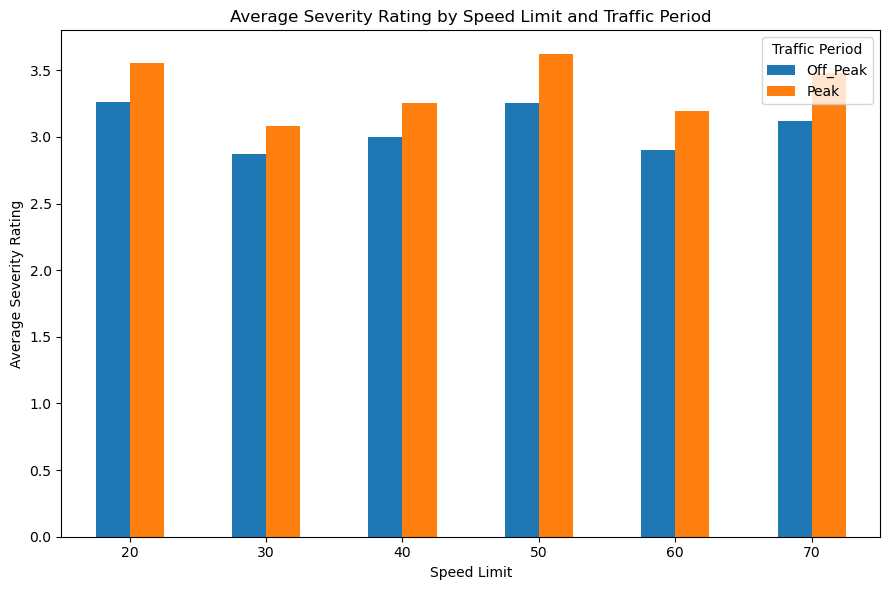

,speed_limit,Peak_Traffic,avg_severity_rating,collision_count
0,20,Off_Peak,3.261,89060
1,20,Peak,3.556,56280
2,30,Off_Peak,2.873,3596481
3,30,Peak,3.081,2283923
4,40,Off_Peak,3.002,419558
5,40,Peak,3.251,282734
6,50,Off_Peak,3.257,109653
7,50,Peak,3.619,75650
8,60,Off_Peak,2.904,934313
9,60,Peak,3.194,585526


In [15]:
# Plot 1: Average severity rating by speed limit and traffic period
# Use pre-crash variables: speed_limit and Peak_Traffic.
# Use severity_rating as the target variable for comparison.

valid_speed_limits = [20, 30, 40, 50, 60, 70]

plot1_df = feature_df.filter(
    col("speed_limit").isin(valid_speed_limits) &
    col("Peak_Traffic").isNotNull() &
    col("severity_rating").isNotNull()
).groupBy(
    "speed_limit", "Peak_Traffic"
).agg(
    round(avg("severity_rating"), 3).alias("avg_severity_rating"),
    count("*").alias("collision_count")
).orderBy(
    "speed_limit", "Peak_Traffic"
)

plot1_pd = plot1_df.toPandas()

# Pivot for grouped bar plot
plot1_pivot = plot1_pd.pivot(
    index="speed_limit",
    columns="Peak_Traffic",
    values="avg_severity_rating"
)

# Plot
ax = plot1_pivot.plot(kind="bar", figsize=(9, 6))

plt.title("Average Severity Rating by Speed Limit and Traffic Period")
plt.xlabel("Speed Limit")
plt.ylabel("Average Severity Rating")
plt.xticks(rotation=0)
plt.legend(title="Traffic Period")
plt.tight_layout()
plt.show()

plot1_pd

### Discussion

#### Plot 1: Average Severity Rating by Speed Limit and Traffic Period

This plot compares the average accident severity rating across different speed limits and traffic periods. It uses `speed_limit` and the engineered `Peak_Traffic` feature as explanatory variables, with `severity_rating` as the target variable. The plot shows that peak traffic periods have higher average severity ratings than off-peak periods across all selected speed limits. For example, at 50 km/h, the average severity rating is 3.619 during peak traffic compared with 3.257 during off-peak traffic. This suggests that traffic period may be associated with accident severity. Although peak traffic may involve slower vehicle movement, it may also involve greater traffic density and more interactions between vehicles and road users. This supports keeping both `speed_limit` and `Peak_Traffic` as useful features for modelling.

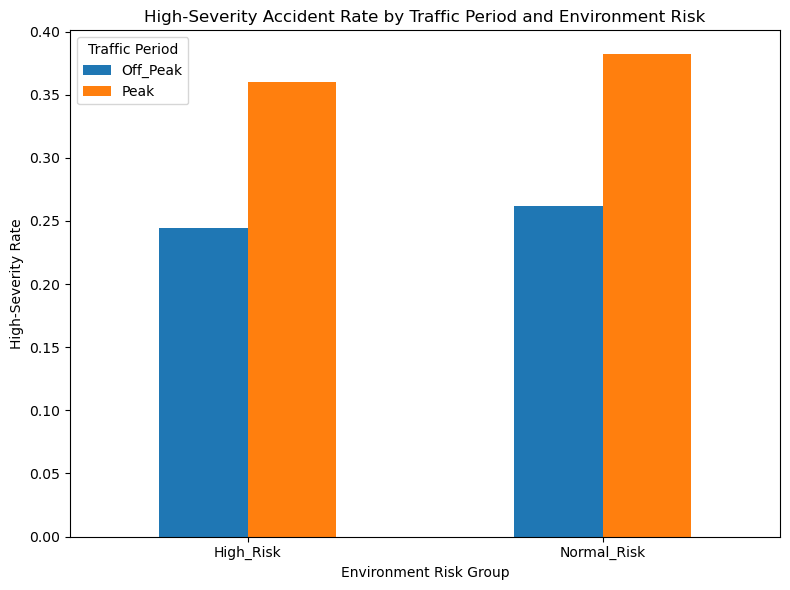

,Peak_Traffic,High_Risk_Environment,total_collisions,high_severity_count,high_severity_rate
0,Off_Peak,High_Risk,2889438,706800,0.2446
1,Peak,High_Risk,1577820,567855,0.3599
2,Off_Peak,Normal_Risk,2610083,684131,0.2621
3,Peak,Normal_Risk,1937759,740002,0.3819


In [16]:
# Plot 2: High-severity accident rate by traffic period and environment risk
# Use pre-crash engineered variables: Peak_Traffic and High_Risk_Environment.
# Define high severity as severity_rating >= 4.

plot2_df = feature_df.filter(
    col("Peak_Traffic").isNotNull() &
    col("High_Risk_Environment").isNotNull() &
    col("severity_rating").isNotNull()
).groupBy(
    "Peak_Traffic", "High_Risk_Environment"
).agg(
    count("*").alias("total_collisions"),
    spark_sum(when(col("severity_rating") >= 4, 1).otherwise(0)).alias("high_severity_count")
).withColumn(
    "high_severity_rate",
    round(col("high_severity_count") / col("total_collisions"), 4)
).orderBy(
    "High_Risk_Environment", "Peak_Traffic"
)

plot2_pd = plot2_df.toPandas()

# Pivot for grouped bar plot
plot2_pivot = plot2_pd.pivot(
    index="High_Risk_Environment",
    columns="Peak_Traffic",
    values="high_severity_rate"
)

# Plot
ax = plot2_pivot.plot(kind="bar", figsize=(8, 6))

plt.title("High-Severity Accident Rate by Traffic Period and Environment Risk")
plt.xlabel("Environment Risk Group")
plt.ylabel("High-Severity Rate")
plt.xticks(rotation=0)
plt.legend(title="Traffic Period")
plt.tight_layout()
plt.show()

plot2_pd

### Discussion

#### Plot 2: High-Severity Accident Rate by Traffic Period and Environment Risk

This plot compares the high-severity accident rate across traffic periods and environmental risk groups. High severity was defined as `severity_rating >= 4`. The plot shows that peak traffic has a higher high-severity rate than off-peak traffic in both environment groups. For high-risk environments, the high-severity rate increases from 0.2446 during off-peak periods to 0.3599 during peak periods. For normal-risk environments, it increases from 0.2621 to 0.3819. This suggests that `Peak_Traffic` is strongly related to the proportion of high-severity accidents. The normal-risk group has a slightly higher high-severity rate than the high-risk group, so environmental risk alone may not fully explain severity. Both engineered features should still be considered in modelling.

## Part 2. Feature extraction and ML training <a class="anchor" name="part-2"></a>
In this section, you must use PySpark DataFrame functions and ML packages for data preparation, model building, and evaluation. Other ML packages, such as scikit-learn, should not be used to process the data; however, it’s fine to use them to display the result or evaluate your model.  
### 2.1 Discuss the feature selection and prepare the feature columns

2.1.1 Based on the data exploration from 1.2 and considering the use case, discuss the importance of those features (For example, which features may be useless and should be removed, which feature has a significant impact on the label column, which should be transformed), which features you are planning to use? Discuss the reasons for selecting them and how you plan to create/transform them.  
○	300 words max for the discussion  
○	Please only use the provided data for model building  
○	You can create/add additional features based on the dataset  
○	Hint - Use the insights from the data exploration/domain knowledge/statistical models to consider whether to create more feature columns, whether to remove some columns  

+ The modelling target is `severity_rating`. Based on the exploration and the use case, I selected features that could reasonably be known before or at the early reporting stage of an accident. Road and environmental variables such as `road_type`, `speed_limit`, `junction_detail`, `junction_control`, `pedestrian_crossing`, `light_conditions`, `weather_conditions`, `road_surface_conditions`, `carriageway_hazards`, `urban_or_rural_area`, and `area` are important because they describe the road layout, traffic setting, visibility, weather, and surface conditions. These factors may influence accident severity.

+ I also selected engineered features from Part 1.2: `hour`, `Peak_Traffic`, and `High_Risk_Environment`. The multivariate plots showed that peak traffic periods had higher average severity ratings and higher high-severity accident rates, so `Peak_Traffic` should be useful. `High_Risk_Environment` combines light, weather, and road surface risks into a simpler interpretable feature.

+ I included aggregated vehicle-related features such as `vehicle_count`, `avg_driver_age`, and `avg_engine_capacity_cc` because they describe accident involvement and vehicle/driver characteristics. The imputed versions of `avg_driver_age` and `avg_engine_capacity_cc` are used to avoid losing records with missing values.

+ Categorical variables will be converted using `StringIndexer` and `OneHotEncoder`, while numeric variables will be kept as continuous features and combined with the encoded categorical variables using `VectorAssembler`.

+ I removed `collision_index` because it is only an identifier. I also removed `date` and `time` because `hour` and `Peak_Traffic` already capture the useful time information. Post-crash casualty variables such as `casualty_count`, `num_driver_or_rider_casualties`, `num_passenger_casualties`, and `num_pedestrian_casualties` were excluded to avoid data leakage, since these are outcomes observed after the crash. Categorical variables will be converted using `StringIndexer` and `OneHotEncoder`, while numeric variables will be kept as continuous features and combined using `VectorAssembler`.

2.1.2 Write code to create/transform the columns based on your discussion above.

In [17]:
from pyspark.sql.functions import col
from pyspark.sql.types import DoubleType, StringType
from pyspark import StorageLevel

# Prepare selected feature columns for ML
# Use the full feature DataFrame created in Part 1.2.
# Select features based on the feature selection discussion above.

feature_df = ml_feature_df

label_col = "severity_rating"

# Numeric features selected for modelling
numeric_feature_cols = [
    "speed_limit",
    "vehicle_count",
    "avg_driver_age",
    "avg_engine_capacity_cc",
    "hour"
]

# Categorical features selected for modelling
# Integer-coded categorical variables are converted to string later
# so that StringIndexer treats them as categories, not continuous numbers.
categorical_feature_cols = [
    "road_type",
    "junction_detail",
    "junction_control",
    "pedestrian_crossing",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "carriageway_hazards",
    "urban_or_rural_area",
    "area",
    "Peak_Traffic",
    "High_Risk_Environment"
]

# Select only the label and selected modelling features
model_df = feature_df.select(
    [label_col] + numeric_feature_cols + categorical_feature_cols
)

# Cast label and numeric features to DoubleType
model_df = model_df.withColumn(label_col, col(label_col).cast(DoubleType()))

for c in numeric_feature_cols:
    model_df = model_df.withColumn(c, col(c).cast(DoubleType()))

# Cast categorical features to StringType
for c in categorical_feature_cols:
    model_df = model_df.withColumn(c, col(c).cast(StringType()))

# Remove rows with missing values in selected modelling columns
# This keeps the modelling data clean before applying Spark ML transformers.

model_df = model_df.na.drop(subset=[label_col] + numeric_feature_cols + categorical_feature_cols)

# Persist because this prepared modelling DataFrame will be reused in Part 2
model_df = model_df.persist(StorageLevel.DISK_ONLY)

# Check prepared modelling DataFrame
print("Number of rows in model_df:", model_df.count())
print("Number of columns in model_df:", len(model_df.columns))

print("Numeric feature columns:")
print(numeric_feature_cols)

print("Categorical feature columns:")
print(categorical_feature_cols)

model_df.printSchema()
model_df.limit(5).show(truncate=False)

Number of rows in model_df: 9015055
Number of columns in model_df: 18
Numeric feature columns:
['speed_limit', 'vehicle_count', 'avg_driver_age', 'avg_engine_capacity_cc', 'hour']
Categorical feature columns:
['road_type', 'junction_detail', 'junction_control', 'pedestrian_crossing', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'carriageway_hazards', 'urban_or_rural_area', 'area', 'Peak_Traffic', 'High_Risk_Environment']
root
 |-- severity_rating: double (nullable = true)
 |-- speed_limit: double (nullable = true)
 |-- vehicle_count: double (nullable = true)
 |-- avg_driver_age: double (nullable = true)
 |-- avg_engine_capacity_cc: double (nullable = true)
 |-- hour: double (nullable = true)
 |-- road_type: string (nullable = true)
 |-- junction_detail: string (nullable = true)
 |-- junction_control: string (nullable = true)
 |-- pedestrian_crossing: string (nullable = true)
 |-- light_conditions: string (nullable = true)
 |-- weather_conditions: string (nullabl

After selecting the modelling columns, I cast numeric variables and the label to `DoubleType` for Spark ML compatibility. Integer-coded categorical variables were cast to `StringType` so that they can be indexed and encoded as categorical features later. Rows with missing values in the selected modelling columns were removed, leaving 9,015,055 records for model preparation.

### 2.2 Preparing Spark ML Transformers/Estimators for features, labels, and models  <a class="anchor" name="2.2"></a>

** Write code to create Transformers/Estimators for transforming/assembling the columns you selected above in 2.1 and create ML model Estimators for Random Forest (RF) and Gradient-boosted tree (GBT) model.
Please DO NOT fit/transform the data yet.**

In [18]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import RandomForestRegressor, GBTRegressor
from pyspark.ml import Pipeline

# Create Spark ML Transformers/Estimators
# This section only defines transformers, estimators, and pipelines.

label_col = "severity_rating"

# Numeric feature columns from 2.1
numeric_feature_cols = [
    "speed_limit",
    "vehicle_count",
    "avg_driver_age",
    "avg_engine_capacity_cc",
    "hour"
]

# Categorical feature columns from 2.1
categorical_feature_cols = [
    "road_type",
    "junction_detail",
    "junction_control",
    "pedestrian_crossing",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "carriageway_hazards",
    "urban_or_rural_area",
    "area",
    "Peak_Traffic",
    "High_Risk_Environment"
]

# StringIndexer for categorical columns
# StringIndexer converts categorical string values into numeric category indexes.

index_output_cols = [c + "_index" for c in categorical_feature_cols]

indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=c + "_index",
        handleInvalid="keep"
    )
    for c in categorical_feature_cols
]

# OneHotEncoder for indexed categorical columns
# OneHotEncoder converts indexed categories into sparse vector columns.

encoded_output_cols = [c + "_vec" for c in categorical_feature_cols]

encoder = OneHotEncoder(
    inputCols=index_output_cols,
    outputCols=encoded_output_cols,
    handleInvalid="keep"
)

# VectorAssembler for final feature vector
# Combine numeric features and encoded categorical features into one features column.

assembler_inputs = numeric_feature_cols + encoded_output_cols

assembler = VectorAssembler(
    inputCols=assembler_inputs,
    outputCol="features",
    handleInvalid="keep"
)

# Create RF and GBT regression estimators
rf_regressor = RandomForestRegressor(
    labelCol=label_col,
    featuresCol="features",
    predictionCol="prediction",
    numTrees=50,
    maxDepth=5,
    seed=42
)

gbt_regressor = GBTRegressor(
    labelCol=label_col,
    featuresCol="features",
    predictionCol="prediction",
    maxIter=50,
    maxDepth=5,
    seed=42
)

print("Transformers and regression estimators created.")
print("Number of StringIndexer stages:", len(indexers))
print("Numeric feature columns:", numeric_feature_cols)
print("Categorical feature columns:", categorical_feature_cols)
print("Assembler input columns:", assembler_inputs)

Transformers and regression estimators created.
Number of StringIndexer stages: 12
Numeric feature columns: ['speed_limit', 'vehicle_count', 'avg_driver_age', 'avg_engine_capacity_cc', 'hour']
Categorical feature columns: ['road_type', 'junction_detail', 'junction_control', 'pedestrian_crossing', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'carriageway_hazards', 'urban_or_rural_area', 'area', 'Peak_Traffic', 'High_Risk_Environment']
Assembler input columns: ['speed_limit', 'vehicle_count', 'avg_driver_age', 'avg_engine_capacity_cc', 'hour', 'road_type_vec', 'junction_detail_vec', 'junction_control_vec', 'pedestrian_crossing_vec', 'light_conditions_vec', 'weather_conditions_vec', 'road_surface_conditions_vec', 'carriageway_hazards_vec', 'urban_or_rural_area_vec', 'area_vec', 'Peak_Traffic_vec', 'High_Risk_Environment_vec']


Justify your choice of using a regression model or multi-class classification model.

+ I chose a regression approach because `severity_rating` is a numeric severity score from 1 to 10. Although the values are discrete, they represent an ordered scale where larger values indicate more severe accidents. Regression keeps this ordering and allows the model to estimate the magnitude of severity. In contrast, multi-class classification would treat each severity level as a separate category and would not directly account for the distance between severity values.

+ For feature transformation, I used `StringIndexer` to convert categorical variables into numeric category indexes, then applied `OneHotEncoder` to represent these indexed categories as sparse vectors. Numeric features were kept as continuous variables. I then used `VectorAssembler` to combine the numeric features and encoded categorical features into a single `features` vector required by Spark ML.

+ Two regression estimators were created: Random Forest Regressor and Gradient-Boosted Tree Regressor. Both models can capture non-linear relationships between road, traffic, environmental, and vehicle-related features. Finally, I created two pipelines, one for RF and one for GBT, each containing 15 stages. No fitting or transformation was performed in this step.

** Write code to include the above Transformers/Estimators into two pipelines.
Please DO NOT fit/transform the data yet.**

In [19]:
# Create two Spark ML pipelines
# Each pipeline contains the same feature transformation stages,
# followed by a different regression estimator.

rf_pipeline = Pipeline(
    stages=indexers + [encoder, assembler, rf_regressor]
)

gbt_pipeline = Pipeline(
    stages=indexers + [encoder, assembler, gbt_regressor]
)

print("RF regression pipeline created.")
print("GBT regression pipeline created.")
print("Number of stages in RF pipeline:", len(rf_pipeline.getStages()))
print("Number of stages in GBT pipeline:", len(gbt_pipeline.getStages()))

RF regression pipeline created.
GBT regression pipeline created.
Number of stages in RF pipeline: 15
Number of stages in GBT pipeline: 15


### 2.3 Training and evaluating models  
2.3.1 Write code to split the data for training and testing, using 2026 as the random seed.

In [20]:
import builtins
from pyspark import StorageLevel

# Split data into training and testing sets
# Use the full prepared modelling DataFrame from Part 2.1.
# Split the data into 70% training and 30% testing using seed 2026.

train_df, test_df = model_df.randomSplit([0.7, 0.3], seed=2026)

# Persist train and test sets because they will be reused for model training and evaluation
train_df = train_df.persist(StorageLevel.DISK_ONLY)
test_df = test_df.persist(StorageLevel.DISK_ONLY)

# Check split sizes
train_count = train_df.count()
test_count = test_df.count()
total_count = train_count + test_count

train_pct = builtins.round(train_count / total_count * 100, 2)
test_pct = builtins.round(test_count / total_count * 100, 2)

print("Training rows:", train_count)
print("Testing rows:", test_count)
print("Total rows:", total_count)
print("Training percentage:", train_pct, "%")
print("Testing percentage:", test_pct, "%")

Training rows: 6309521
Testing rows: 2705534
Total rows: 9015055
Training percentage: 69.99 %
Testing percentage: 30.01 %


The prepared modelling DataFrame was split into training and testing sets using a 70/30 random split with seed 2026. The resulting training set contains 6,309,521 rows, representing 69.99% of the data, while the testing set contains 2,705,534 rows, representing 30.01% of the data. This is consistent with the required 70/30 split. The training data will be used to fit the Random Forest and Gradient-Boosted Tree regression pipelines, while the testing data will be used to evaluate model performance on unseen records.

2.3.2 Decide which metric is the best and implement the evaluation process.

+ Since I chose regression models, I used regression evaluation metrics instead of classification metrics such as accuracy, precision, recall, or F1-score. The main metric selected for model comparison is RMSE because it measures the average prediction error in the same unit as the severity rating and gives stronger penalty to larger errors. This is useful because large mistakes in accident severity prediction are more serious than small errors.

+ I also used MAE and R2 as supporting metrics. MAE measures the average absolute prediction error and is easier to interpret because it shows how far the prediction is from the true severity rating on average. R2 measures how much variation in severity rating is explained by the model. A lower RMSE and MAE indicate better prediction performance, while a higher R2 indicates a better fit.

In [21]:
from pyspark.ml.evaluation import RegressionEvaluator

# Define regression evaluation process
# Since severity_rating is treated as a numeric target,
# regression metrics are used for evaluation.

rmse_evaluator = RegressionEvaluator(
    labelCol=label_col,
    predictionCol="prediction",
    metricName="rmse"
)

mae_evaluator = RegressionEvaluator(
    labelCol=label_col,
    predictionCol="prediction",
    metricName="mae"
)

r2_evaluator = RegressionEvaluator(
    labelCol=label_col,
    predictionCol="prediction",
    metricName="r2"
)

# Function to evaluate a regression model using RMSE, MAE, and R2
def evaluate_regression_model(predictions, model_name):
    rmse = rmse_evaluator.evaluate(predictions)
    mae = mae_evaluator.evaluate(predictions)
    r2 = r2_evaluator.evaluate(predictions)
    
    print(model_name + " Evaluation Metrics")
    print("-" * 55)
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)
    
    return {
        "model": model_name,
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    }

print("Regression evaluators created.")
print("Main comparison metric: RMSE")

Regression evaluators created.
Main comparison metric: RMSE


2.3.3 Train, evaluate and Save the better model (you’ll need it for A2B).
(Note: You may need to go through a few training loops or use more data to create a better-performing model.)

In [22]:
import pandas as pd

# Train and evaluate Random Forest regression pipeline
print("Training Random Forest regression pipeline...")
rf_model = rf_pipeline.fit(train_df)

print("Generating Random Forest predictions...")
rf_predictions = rf_model.transform(test_df)

rf_metrics = evaluate_regression_model(
    rf_predictions,
    "Random Forest Regressor"
)

Training Random Forest regression pipeline...
Generating Random Forest predictions...
Random Forest Regressor Evaluation Metrics
-------------------------------------------------------
RMSE: 0.7095871604293394
MAE : 0.5474277512893514
R2  : 0.5391315634290481


In [23]:
# Train and evaluate Gradient-Boosted Tree regression pipeline
print("Training Gradient-Boosted Tree regression pipeline...")
gbt_model = gbt_pipeline.fit(train_df)

print("Generating GBT predictions...")
gbt_predictions = gbt_model.transform(test_df)

gbt_metrics = evaluate_regression_model(
    gbt_predictions,
    "Gradient-Boosted Tree Regressor"
)

Training Gradient-Boosted Tree regression pipeline...
Generating GBT predictions...
Gradient-Boosted Tree Regressor Evaluation Metrics
-------------------------------------------------------
RMSE: 0.6539710670701624
MAE : 0.4830602437175341
R2  : 0.608544375041232


In [24]:
# Compare model performance
metrics_pd = pd.DataFrame([rf_metrics, gbt_metrics])

metrics_pd

,model,rmse,mae,r2
0,Random Forest Regressor,0.709587,0.547428,0.539132
1,Gradient-Boosted Tree Regressor,0.653971,0.483060,0.608544


In [25]:
# Select and save the better model
# Lower RMSE is better, so RMSE is used as the main selection metric.

if rf_metrics["rmse"] <= gbt_metrics["rmse"]:
    best_model = rf_model
    best_model_name = "Random Forest Regressor"
    best_rmse = rf_metrics["rmse"]
else:
    best_model = gbt_model
    best_model_name = "Gradient-Boosted Tree Regressor"
    best_rmse = gbt_metrics["rmse"]

print("Best model:", best_model_name)
print("Best RMSE:", best_rmse)

# Save the better model for Assignment 2B
best_model_path = "A2A_best_severity_model"

best_model.write().overwrite().save(best_model_path)

print("Best model saved to:", best_model_path)

Best model: Gradient-Boosted Tree Regressor
Best RMSE: 0.6539710670701624
Best model saved to: A2A_best_severity_model


### Discussion

+ Both Random Forest and Gradient-Boosted Tree regression pipelines were trained using the training dataset and evaluated using the testing dataset. The models were compared using RMSE as the main metric, with MAE and R2 used as supporting metrics.

+ The Random Forest model achieved an RMSE of 0.7096, MAE of 0.5474, and R2 of 0.5391. The Gradient-Boosted Tree model achieved an RMSE of 0.6540, MAE of 0.4831, and R2 of 0.6085. Since the GBT model had a lower RMSE and MAE, and a higher R2, it performed better overall.

Therefore, the Gradient-Boosted Tree Regressor was selected as the better model and saved as `A2A_best_severity_model` for use in Part B of Assignment 2.

### Part 3. Hyperparameter Tuning and Model Optimisation <a class="anchor" name="part-3"></a>  
Apply the techniques you have learnt from the labs, for example, CrossValidator, TrainValidationSplit, ParamGridBuilder, etc., to perform further hyperparameter tuning and model optimisation.  
The assessment is based on the quality of your work/process, not the quality of your model. Please include your thoughts/ideas/discussions.

In [26]:
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit
from pyspark.ml.evaluation import RegressionEvaluator

# Hyperparameter tuning for the better model
# The better model from Part 2 was the Gradient-Boosted Tree Regressor.
# TrainValidationSplit is used because it is less expensive than CrossValidator.

tuning_evaluator = RegressionEvaluator(
    labelCol=label_col,
    predictionCol="prediction",
    metricName="rmse"
)

# Build parameter grid for GBT
# A small grid is used because GBT training on the full dataset is computationally expensive.
# RMSE is used as the tuning metric, so lower values are better.

gbt_param_grid = (
    ParamGridBuilder()
    .addGrid(gbt_regressor.maxDepth, [4, 5])
    .addGrid(gbt_regressor.maxIter, [30])
    .addGrid(gbt_regressor.stepSize, [0.1])
    .build()
)

print("Number of hyperparameter combinations:", len(gbt_param_grid))

Number of hyperparameter combinations: 2


In [27]:
# Create TrainValidationSplit object
# trainRatio=0.8 means 80% of train_df is used for fitting
# and 20% is used internally for validation during tuning.

gbt_tvs = TrainValidationSplit(
    estimator=gbt_pipeline,
    estimatorParamMaps=gbt_param_grid,
    evaluator=tuning_evaluator,
    trainRatio=0.8,
    seed=2026,
    parallelism=1
)

print("TrainValidationSplit object created for GBT tuning.")

TrainValidationSplit object created for GBT tuning.


In [28]:
# Fit the tuning model
print("Starting GBT hyperparameter tuning...")

gbt_tuned_model = gbt_tvs.fit(train_df)

print("GBT hyperparameter tuning completed.")

Starting GBT hyperparameter tuning...
GBT hyperparameter tuning completed.


In [29]:
# Evaluate tuned model on test data
print("Generating predictions from tuned GBT model...")

gbt_tuned_predictions = gbt_tuned_model.transform(test_df)

gbt_tuned_metrics = evaluate_regression_model(
    gbt_tuned_predictions,
    "Tuned Gradient-Boosted Tree Regressor"
)

Generating predictions from tuned GBT model...
Tuned Gradient-Boosted Tree Regressor Evaluation Metrics
-------------------------------------------------------
RMSE: 0.6564620912112776
MAE : 0.4854925520777705
R2  : 0.6055565285644265


In [30]:
# Inspect best model parameters
best_tuned_pipeline_model = gbt_tuned_model.bestModel

# The final stage in the pipeline is the GBTRegressionModel
best_gbt_stage = best_tuned_pipeline_model.stages[-1]

print("Best tuned GBT parameters:")
print("maxDepth:", best_gbt_stage.getMaxDepth())
print("maxIter:", best_gbt_stage.getMaxIter())
print("stepSize:", best_gbt_stage.getStepSize())

Best tuned GBT parameters:
maxDepth: 5
maxIter: 30
stepSize: 0.1


In [31]:
# Compare baseline GBT and tuned GBT
tuning_compare_pd = pd.DataFrame([
    gbt_metrics,
    gbt_tuned_metrics
])

tuning_compare_pd

,model,rmse,mae,r2
0,Gradient-Boosted Tree Regressor,0.653971,0.483060,0.608544
1,Tuned Gradient-Boosted Tree Regressor,0.656462,0.485493,0.605557


In [32]:
# Save tuned model if better than Part 2 best model
# Lower RMSE is better.

baseline_best_rmse = best_rmse
tuned_rmse = gbt_tuned_metrics["rmse"]

if tuned_rmse < baseline_best_rmse:
    final_model = gbt_tuned_model.bestModel
    final_model_name = "Tuned Gradient-Boosted Tree Regressor"
    final_model_path = "A2A_tuned_best_severity_model"
    
    final_model.write().overwrite().save(final_model_path)
    
    print("Tuned model improved performance.")
    print("Final model:", final_model_name)
    print("Tuned RMSE:", tuned_rmse)
    print("Baseline best RMSE:", baseline_best_rmse)
    print("Final tuned model saved to:", final_model_path)
else:
    final_model = best_model
    final_model_name = best_model_name
    final_model_path = best_model_path
    
    print("Tuned model did not improve performance.")
    print("Keeping Part 2 best model:", final_model_name)
    print("Tuned RMSE:", tuned_rmse)
    print("Baseline best RMSE:", baseline_best_rmse)
    print("Existing best model remains saved at:", final_model_path)

Tuned model did not improve performance.
Keeping Part 2 best model: Gradient-Boosted Tree Regressor
Tuned RMSE: 0.6564620912112776
Baseline best RMSE: 0.6539710670701624
Existing best model remains saved at: A2A_best_severity_model


### Discussion

- The Gradient-Boosted Tree Regressor was selected for hyperparameter tuning because it was the better-performing model from Part 2. It achieved a lower RMSE and MAE, and a higher R2 than the Random Forest Regressor.
- I used `TrainValidationSplit` with `ParamGridBuilder` to tune the GBT model. `TrainValidationSplit` was chosen instead of `CrossValidator` because the dataset is large and GBT training is computationally expensive. This approach still provides a systematic validation process while reducing the training cost compared with k-fold cross-validation.

RMSE was used as the tuning metric because it was also the main evaluation metric in Part 2. RMSE is suitable for this regression task because it measures prediction error in the severity rating scale and penalises larger errors more strongly.

The tuned parameters were `maxDepth`, `maxIter`, and `stepSize`. `maxDepth` controls the complexity of each tree, `maxIter` controls the number of boosting iterations, and `stepSize` controls the learning rate. The parameter grid tested `maxDepth` values of 4 and 5, `maxIter` value of 30, and `stepSize` value of 0.1, giving two hyperparameter combinations in total. The grid was kept small because the dataset contains over 9 million records and GBT training is computationally expensive. The best tuned parameters were:

- `maxDepth`: 5
- `maxIter`: 30
- `stepSize`: 0.1

The tuned GBT model achieved an RMSE of 0.6565, MAE of 0.4855, and R2 of 0.6056. Compared with the Part 2 GBT model, which achieved an RMSE of 0.6540, MAE of 0.4831, and R2 of 0.6085, the tuned model did not improve performance. The tuned model had a slightly higher RMSE and MAE and a slightly lower R2. Therefore, the original Part 2 Gradient-Boosted Tree Regressor was kept as the final model and remains saved as `A2A_best_severity_model`.

## References:
Please add your references below: